In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
from dask import delayed
import pyarrow as pa
import pyarrow.parquet as pq
import glob

try:
    project_root = Path.cwd().parent
except NameError:
    project_root = Path('/scistor/guest/gbb083/AeroCom')
py_dir = project_root / 'py'
if str(py_dir) not in sys.path:
    sys.path.insert(0, str(py_dir))
sys.path.append(py_dir)
SPEXone_folder = project_root / 'Data' / 'SPEXone'


In [20]:
# ----  if all dates are complete in the spex files ----
spex_files = sorted(glob.glob(str(SPEXone_folder / 'Extract*L2*.parquet')))
# 
print(f'Checking {len(spex_files)} SPEXone files for missing dates...')
for f in spex_files:
    print(f'Checking {f}')
    test = pd.read_parquet(f) 
    ts_spex = pd.to_datetime(test['date'],utc=True).dt.round('D')
    full = pd.date_range(ts_spex.min(), ts_spex.max(), freq='D')
    missing = full.difference(ts_spex)
    print(f'it has {len(missing)} missing dates: {missing.values}')

    

Checking 37 SPEXone files for missing dates...
Checking /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/SPEXone/Extract_PACE_SPEXONE_L2_AER_RTAPLAND_2024_06_v4.0.parquet
it has 0 missing dates: []
Checking /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/SPEXone/Extract_PACE_SPEXONE_L2_AER_RTAPLAND_2024_07_v4.0.parquet
it has 0 missing dates: []
Checking /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/SPEXone/Extract_PACE_SPEXONE_L2_AER_RTAPLAND_2024_08_v4.0.parquet
it has 9 missing dates: ['2024-08-19T00:00:00.000000000' '2024-08-20T00:00:00.000000000'
 '2024-08-23T00:00:00.000000000' '2024-08-24T00:00:00.000000000'
 '2024-08-25T00:00:00.000000000' '2024-08-26T00:00:00.000000000'
 '2024-08-27T00:00:00.000000000' '2024-08-28T00:00:00.000000000'
 '2024-08-29T00:00:00.000000000']
Checking /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/SPEXone/Extract_PACE_SPEXONE_L2_AER_RTAPLAND_2024_09_v4.0.parquet
it has 2 missing 

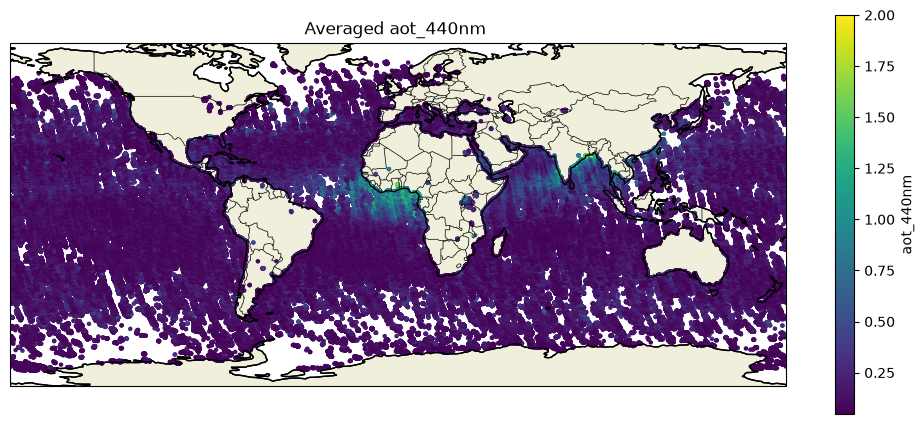

ploted aot_440nm


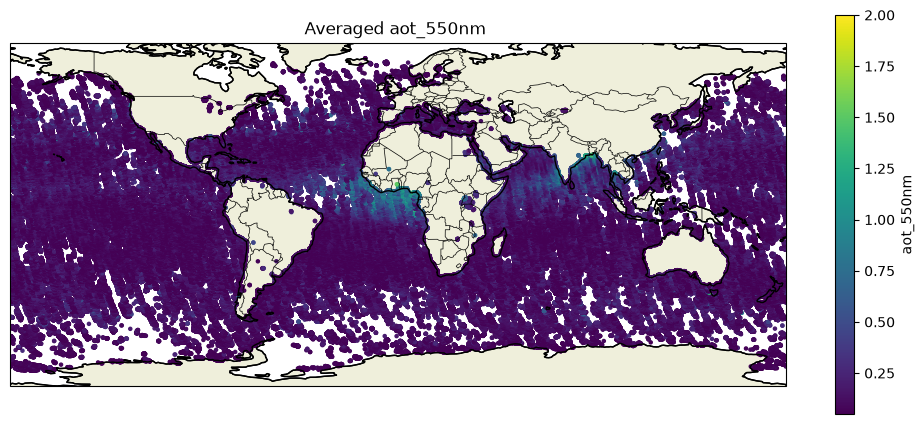

ploted aot_550nm


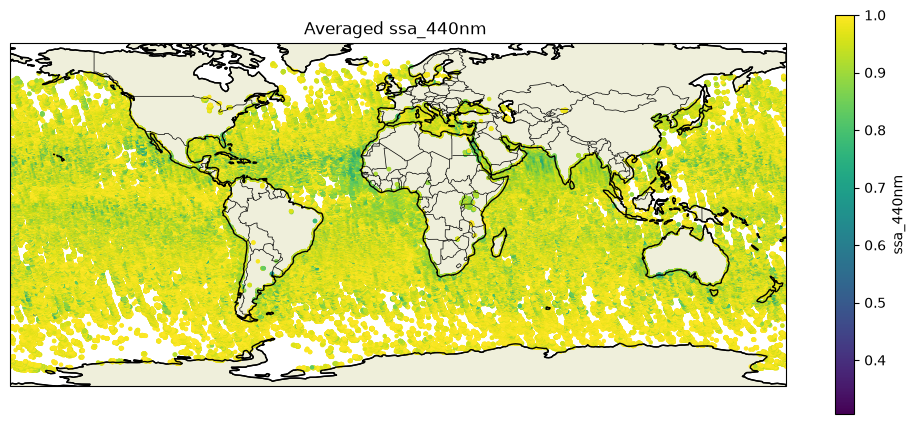

ploted ssa_440nm


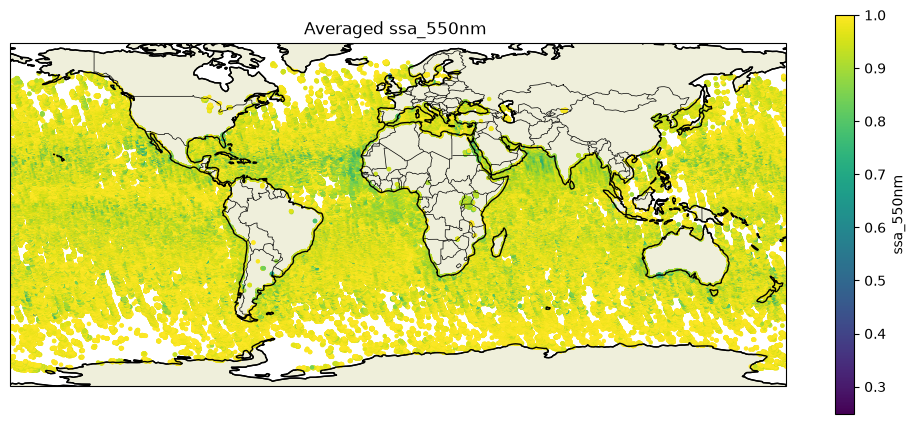

ploted ssa_550nm


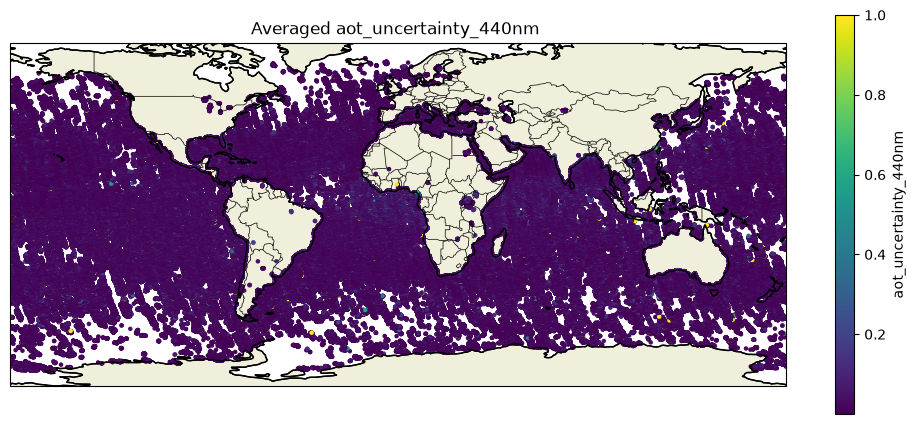

ploted aot_uncertainty_440nm


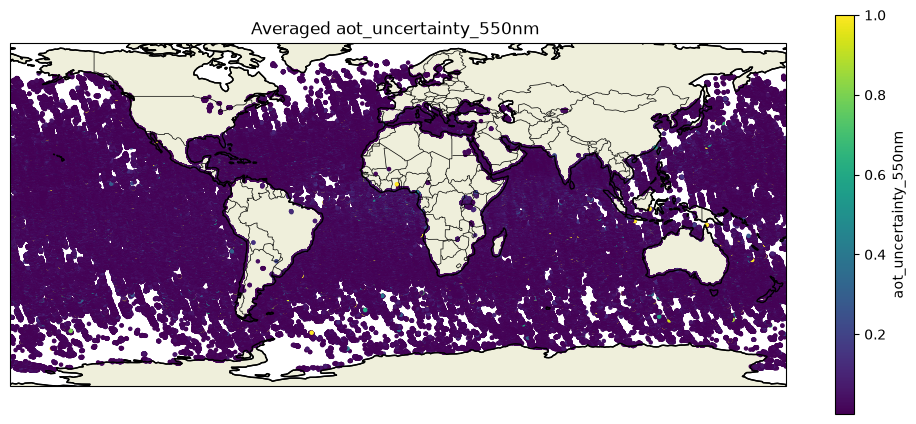

ploted aot_uncertainty_550nm


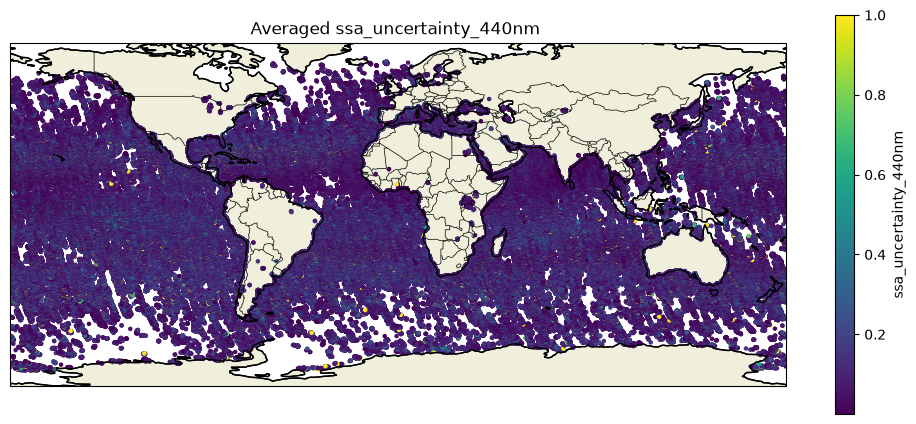

ploted ssa_uncertainty_440nm


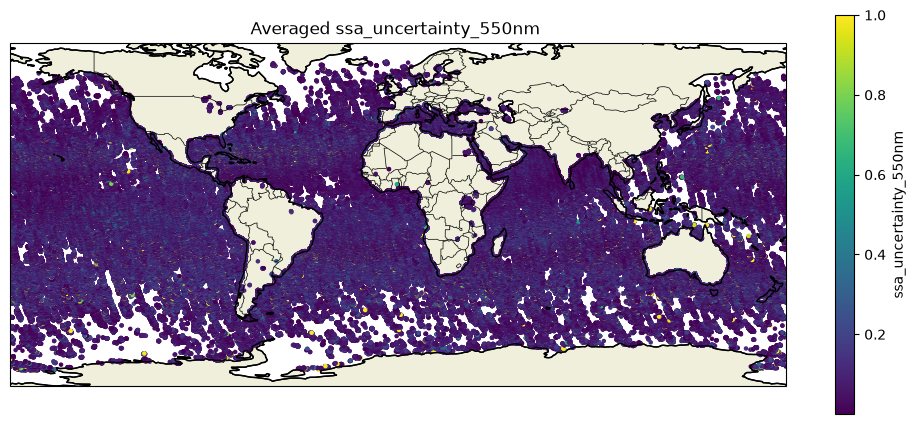

ploted ssa_uncertainty_550nm


In [ ]:
TEST_F = glob.glob(str(SPEXone_folder / '*L2*OCEAN*2025_02*.parquet'))
print(TEST_F)
df = pd.read_parquet(TEST_F)
# wvl = [340, 355, 380, 440, 500, 532, 550, 670, 865, 1020, 1064]
wvl = [ 440,  550  ]
var_key = ['aot', 'ssa', 'aot_uncertainty', 'ssa_uncertainty']
vmax_var = {'aot': 1, 
            'aod': 1, 
           'ssa': 1, 
           'aot_uncertainty':.5 , 
           'aod_uncertainty':0.5 , 
           'ssa_uncertainty': 0.5}
vars = [f"{key}_{wl}nm" for key in var_key for wl in wvl] 

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt 

feature_cols = [col for col in df.columns if col not in ["lat", "lon", "date"]]
for plot_var in vars:
    # plot_var = 'mi'
    # Group by lat/lon and average the selected variable
    df_avg = df.groupby(["lat", "lon"])[plot_var].mean().reset_index()
    v, rest = plot_var.rsplit("_", 1)
    # ---- Step 3: Plot on map ----
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    sc = ax.scatter(
        df_avg["lon"],
        df_avg["lat"],
        c=df_avg[plot_var],
        cmap="viridis",
        s=5,
        vmax = vmax_var[v],
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black")
    ax.set_title(f"Averaged {plot_var} ")
    plt.colorbar(sc, label=plot_var, orientation="vertical", shrink=0.7)
    plt.tight_layout()
    plt.show()
    print(f"ploted {plot_var}")
    # plt.savefig(f'~/Desktop/SPEXone_annual_{plot_var}_average.png')

In [19]:
df[df["ssa_uncertainty_440nm"] > 0.7].count()
# df[df["aot_uncertainty_440nm"] > 1].count()

lat                      3904
lon                      3904
date                     3904
aot_340nm                3904
aot_355nm                3904
aot_380nm                3904
aot_440nm                3904
aot_490nm                3904
aot_500nm                3904
aot_532nm                3904
aot_550nm                3904
aot_565nm                3904
aot_670nm                3904
aot_675nm                3904
aot_865nm                3904
aot_uncertainty_340nm    3904
aot_uncertainty_355nm    3904
aot_uncertainty_380nm    3904
aot_uncertainty_440nm    3904
aot_uncertainty_490nm    3904
aot_uncertainty_500nm    3904
aot_uncertainty_532nm    3904
aot_uncertainty_550nm    3904
aot_uncertainty_565nm    3904
aot_uncertainty_670nm    3904
aot_uncertainty_675nm    3904
aot_uncertainty_865nm    3904
ssa_340nm                3904
ssa_355nm                3904
ssa_380nm                3904
ssa_440nm                3904
ssa_490nm                3904
ssa_500nm                3904
ssa_532nm 

In [17]:
df['ssa_uncertainty_440nm'].agg(["min", "median", "max"])

min          0.000052
median       0.078898
max       3843.656738
Name: ssa_uncertainty_440nm, dtype: float32

In [31]:
spex_grid_files = sorted(glob.glob(str(project_root / 'Data' /'SPEXone_regridded' / '*.parquet')))

test = pd.read_parquet(spex_grid_files[0]) 
test.columns

Index(['lon_bin', 'lat_bin', 'date', 'n', 'aod_340nm', 'spread_aod_340nm',
       'regrid_err_aod_340nm', 'aaod_340nm', 'spread_aaod_340nm',
       'regrid_err_aaod_340nm', 'aod_355nm', 'spread_aod_355nm',
       'regrid_err_aod_355nm', 'aaod_355nm', 'spread_aaod_355nm',
       'regrid_err_aaod_355nm', 'aod_380nm', 'spread_aod_380nm',
       'regrid_err_aod_380nm', 'aaod_380nm', 'spread_aaod_380nm',
       'regrid_err_aaod_380nm', 'aod_440nm', 'spread_aod_440nm',
       'regrid_err_aod_440nm', 'aaod_440nm', 'spread_aaod_440nm',
       'regrid_err_aaod_440nm', 'aod_500nm', 'spread_aod_500nm',
       'regrid_err_aod_500nm', 'aaod_500nm', 'spread_aaod_500nm',
       'regrid_err_aaod_500nm', 'aod_532nm', 'spread_aod_532nm',
       'regrid_err_aod_532nm', 'aaod_532nm', 'spread_aaod_532nm',
       'regrid_err_aaod_532nm', 'aod_550nm', 'spread_aod_550nm',
       'regrid_err_aod_550nm', 'aaod_550nm', 'spread_aaod_550nm',
       'regrid_err_aaod_550nm', 'aod_670nm', 'spread_aod_670nm',
       '

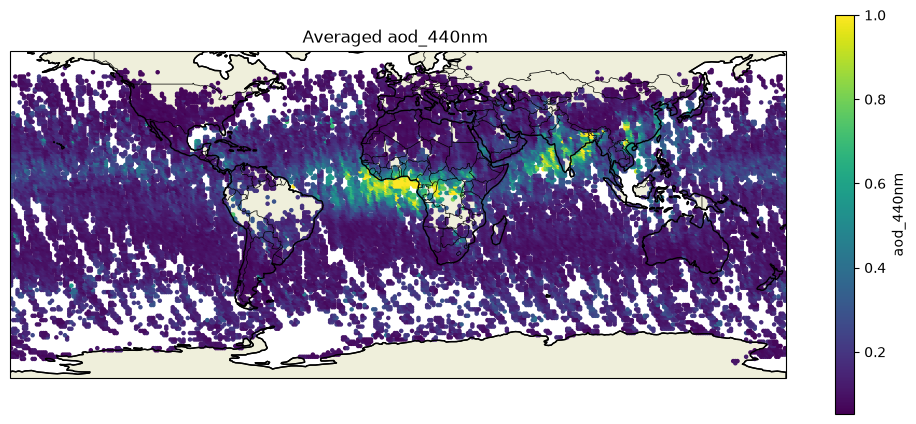

ploted aod_440nm


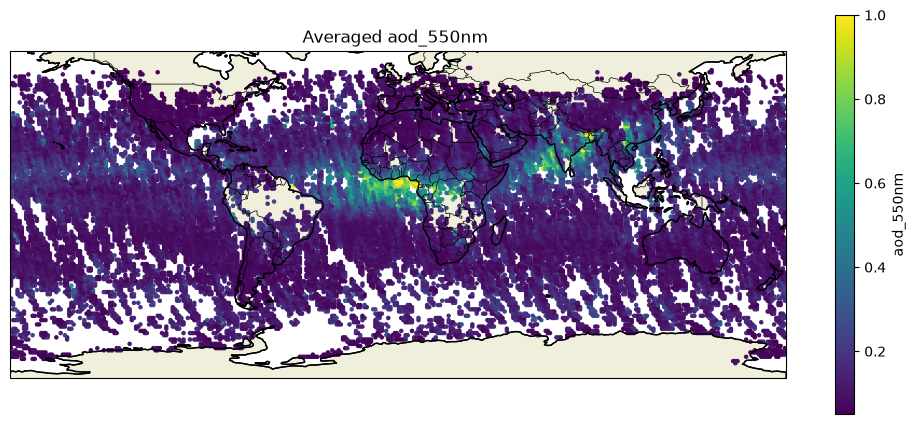

ploted aod_550nm


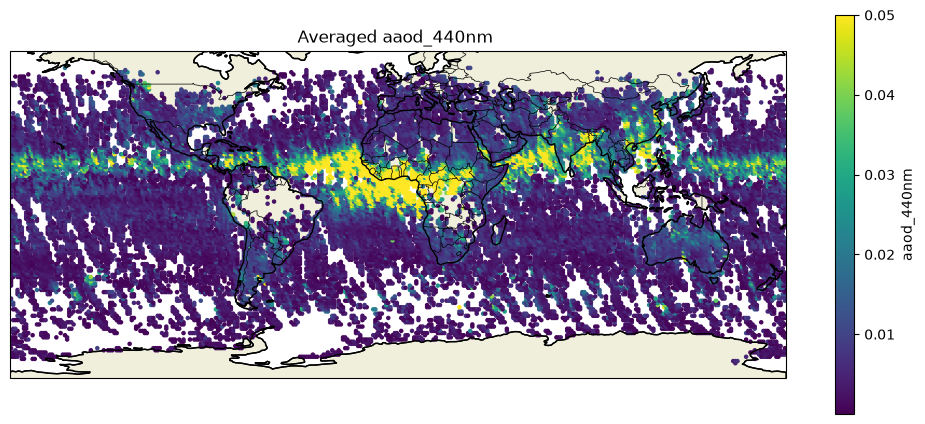

ploted aaod_440nm


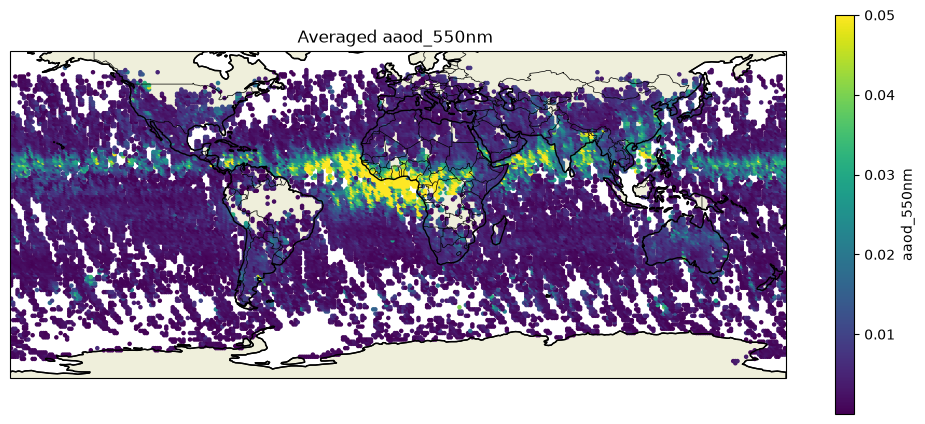

ploted aaod_550nm


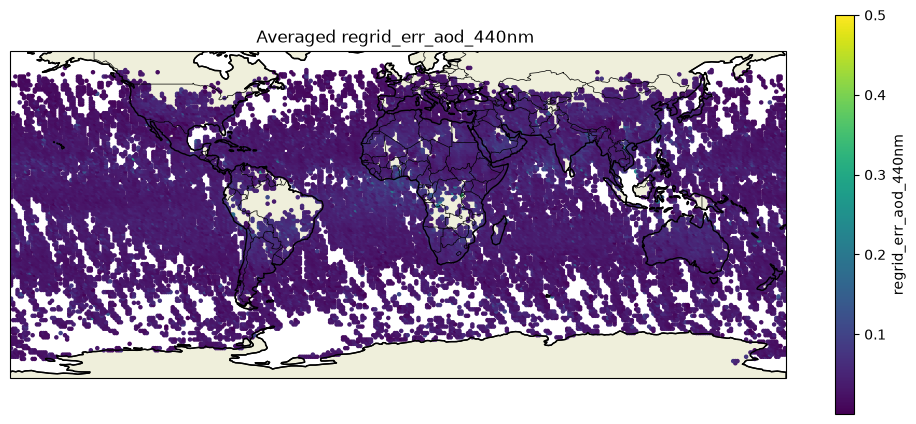

ploted regrid_err_aod_440nm


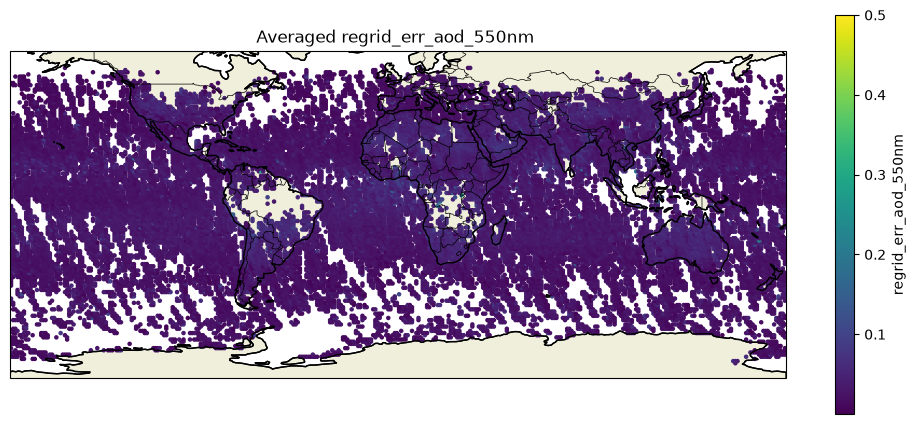

ploted regrid_err_aod_550nm


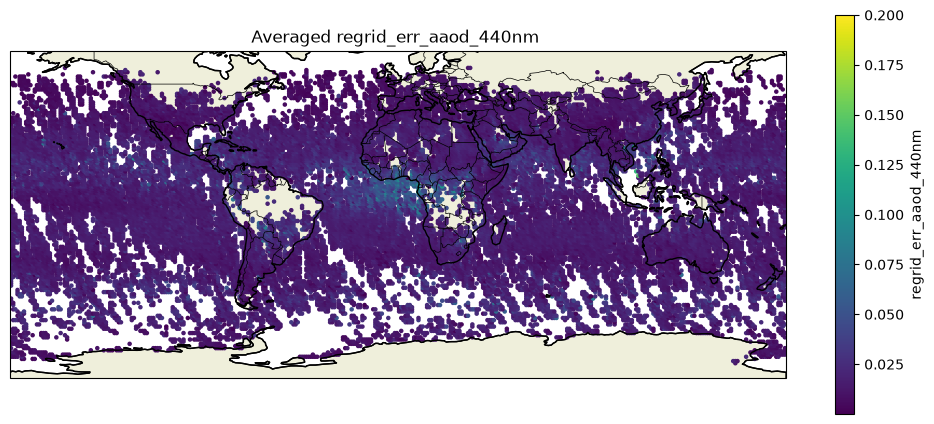

ploted regrid_err_aaod_440nm


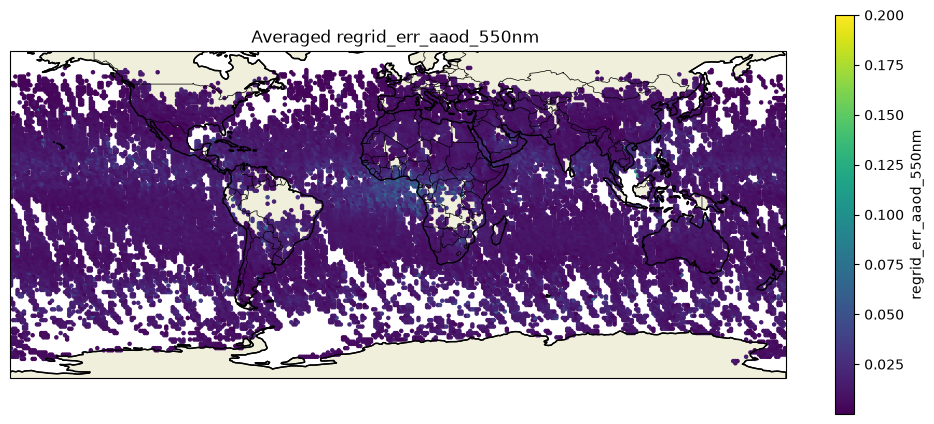

ploted regrid_err_aaod_550nm


In [40]:
 
# wvl = [340, 355, 380, 440, 500, 532, 550, 670, 865, 1020, 1064]
wvl = [ 440,  550  ]
var_key = ['aod', 'aaod', 'regrid_err_aod', 'regrid_err_aaod'] 
vmax_var = {'aot': 1, 
            'aod': 1, 
            'aaod':0.05,
            'regrid_err_aod': .5,
            'regrid_err_aaod': .2,
           'ssa': 1, 
           'regrid_err':.5 , 
           'aod_uncertainty':0.5 , 
           'ssa_uncertainty': 0.5}
vars = [f"{key}_{wl}nm" for key in var_key for wl in wvl] 

for plot_var in vars:
    # plot_var = 'mi'
    # Group by lat/lon and average the selected variable
    df_avg = test.groupby(["lat_bin", "lon_bin"])[plot_var].mean().reset_index()
    v, rest = plot_var.rsplit("_", 1)
    # ---- Step 3: Plot on map ----
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    sc = ax.scatter(
        df_avg["lon_bin"],
        df_avg["lat_bin"],
        c=df_avg[plot_var],
        cmap="viridis",
        s=5,
        vmax = vmax_var[v],
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black")
    ax.set_title(f"Averaged {plot_var} ")
    plt.colorbar(sc, label=plot_var, orientation="vertical", shrink=0.7)
    plt.tight_layout()
    plt.show()
    print(f"ploted {plot_var}")
    # plt.savefig(f'~/Desktop/SPEXone_annual_{plot_var}_average.png')

In [38]:
test['regrid_err_aaod_550nm'].agg(["min", "median", "max"])

min       0.000038
median    0.011200
max       0.120994
Name: regrid_err_aaod_550nm, dtype: float32

In [39]:
test['regrid_err_aod_550nm'].agg(["min", "median", "max"])

min       0.000051
median    0.028849
max       0.299296
Name: regrid_err_aod_550nm, dtype: float32

In [ ]:
GPCP_folder = project_root / 'Data' / 'Prec'
prec_daily = glob.glob(str(GPCP_folder / 'GPCPDAY_L3_*.nc4'))
xr.open_dataset(prec_daily[0:20]).precip.mean(dim='time').plot()

In [ ]:
prec_df = xr.open_mfdataset(prec_daily[0:20]).to_dataframe().reset_index()